<a href="https://colab.research.google.com/github/xXLukaENPXx/Triatletas/blob/main/Analisis_espectral_(Triatletas).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **PSD POR BANDAS (PROMEDIO)**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


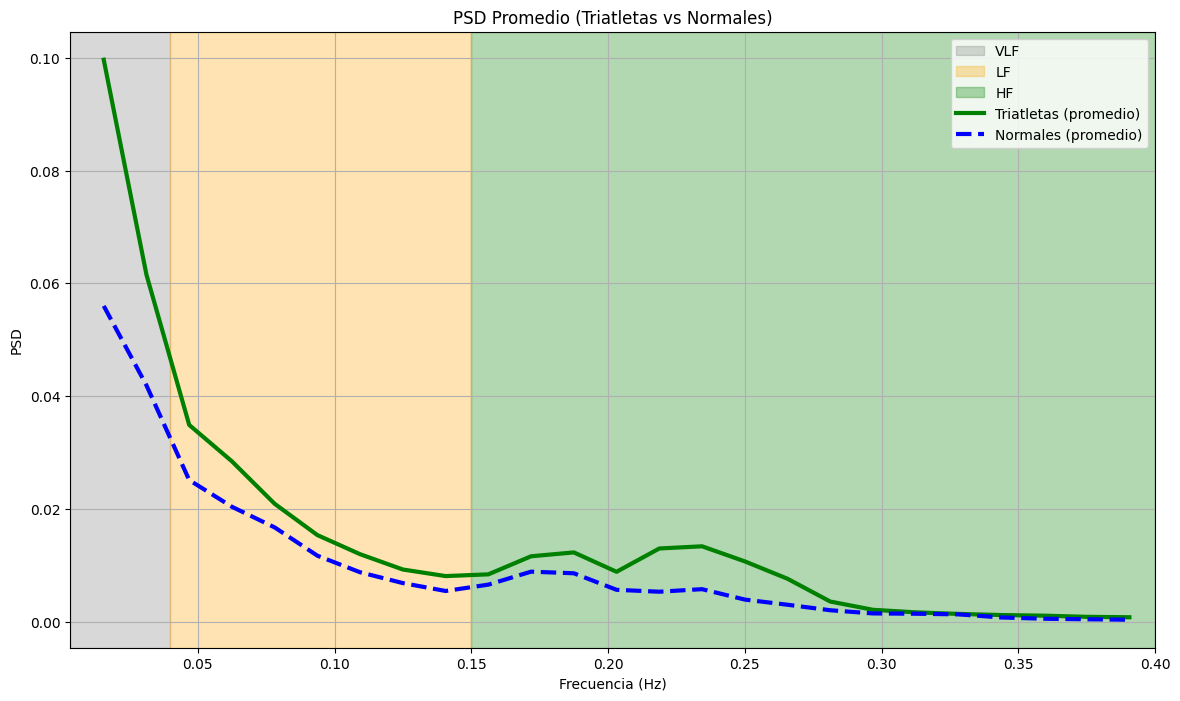

                 VLF        LF        HF
Triatletas  0.001259  0.001676  0.001460
Normales    0.000765  0.001243  0.000814


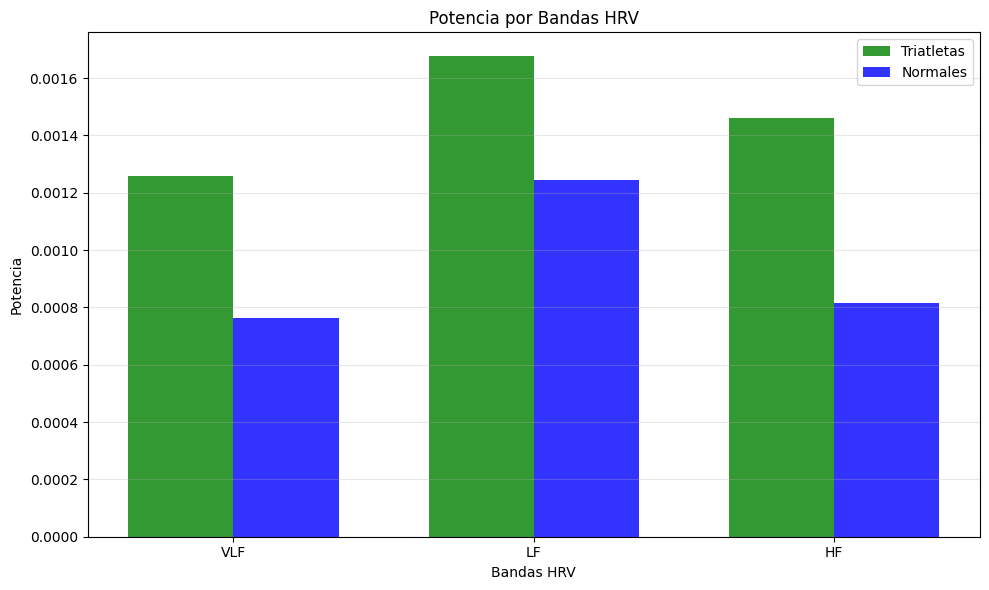

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import pandas as pd

# ============================================
# Montar Drive
# ============================================

from google.colab import drive
drive.mount('/content/drive')

# ============================================
# Paths
# ============================================

triatleta_paths = [
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I9_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I8_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I7_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I6_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I5_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I4_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I3_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I2_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I1_RR.txt"
]

normal_paths = [
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N11_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N10_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N9_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N8_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N7_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N6_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N5_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N4_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N2_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N1_RR.txt"
]

# ============================================
# Bandas HRV
# ============================================

bands = {
    "VLF": (0.0033, 0.04),
    "LF": (0.04, 0.15),
    "HF": (0.15, 0.40)
}

band_colors = {
    "VLF": "gray",
    "LF": "orange",
    "HF": "green"
}

# ============================================
# Funciones
# ============================================

def load_rr(path):
    rr = np.loadtxt(path)
    if np.mean(rr) > 10:
        rr = rr / 1000  # ms → s
    return rr


def compute_psd(rr):
    fs = 4  # Hz (interpolación estándar HRV)

    t = np.cumsum(rr)
    t_interp = np.arange(0, t[-1], 1/fs)

    rr_interp = np.interp(t_interp, t, rr)

    f, psd = welch(rr_interp, fs=fs, nperseg=256)

    return f, psd


def band_power(f, psd):
    power = {}
    for band in bands:
        low, high = bands[band]
        mask = (f >= low) & (f <= high)
        power[band] = np.trapezoid(psd[mask], f[mask])
    return power


# ============================================
# PSD TRIATLETAS (PROMEDIO)
# ============================================

rr_triatletas = [load_rr(p) for p in triatleta_paths]

psd_triatletas = []

for rr in rr_triatletas:
    f_tri, psd_tri = compute_psd(rr)
    psd_triatletas.append(psd_tri)

psd_triatletas = np.array(psd_triatletas)
psd_tri_mean = np.mean(psd_triatletas, axis=0)

f_common = f_tri  # referencia


# ============================================
# PSD NORMALES (PROMEDIO + INTERPOLACIÓN)
# ============================================

rr_normales = [load_rr(p) for p in normal_paths]

psd_normales_interp = []

for rr in rr_normales:
    f_norm, psd_norm = compute_psd(rr)

    # interpolar para alinear frecuencias
    psd_interp = np.interp(f_common, f_norm, psd_norm)

    psd_normales_interp.append(psd_interp)

psd_normales_interp = np.array(psd_normales_interp)
psd_norm_mean = np.mean(psd_normales_interp, axis=0)


# ============================================
# GRAFICA PSD ACOTADA A BANDAS HRV
# ============================================

plt.figure(figsize=(14,8))

f_min, f_max = 0.0033, 0.40
mask = (f_common >= f_min) & (f_common <= f_max)

# sombreado de bandas
for band in bands:
    low, high = bands[band]
    plt.axvspan(low, high, color=band_colors[band], alpha=0.3, label=band)

# PSD Triatletas (VERDE)
plt.plot(f_common[mask], psd_tri_mean[mask],
         linewidth=3, color='green', label="Triatletas (promedio)")

# PSD Normales (AZUL)
plt.plot(f_common[mask], psd_norm_mean[mask],
         linewidth=3, linestyle="--", color='blue',
         label="Normales (promedio)")

plt.xlim(f_min, f_max)

plt.title("PSD Promedio (Triatletas vs Normales)")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD")
plt.legend()
plt.grid()

plt.show()


# ============================================
# POTENCIA POR BANDAS
# ============================================

power_tri = band_power(f_common, psd_tri_mean)
power_norm = band_power(f_common, psd_norm_mean)

df = pd.DataFrame({
    "Triatletas": power_tri,
    "Normales": power_norm
}).T

print(df)


# ============================================
# GRAFICO DE BARRAS (CON COLORES POR BANDA)
# ============================================

fig, ax = plt.subplots(figsize=(10,6))

# Crear el gráfico de barras manualmente para controlar los colores
x = np.arange(len(bands))
width = 0.35

# Barras para triatletas (verde) y normales (azul)
bars_tri = ax.bar(x - width/2, [power_tri[band] for band in bands],
                   width, label='Triatletas', color='green', alpha=0.8)
bars_norm = ax.bar(x + width/2, [power_norm[band] for band in bands],
                    width, label='Normales', color='blue', alpha=0.8)

ax.set_xlabel('Bandas HRV')
ax.set_ylabel('Potencia')
ax.set_title('Potencia por Bandas HRV')
ax.set_xticks(x)
ax.set_xticklabels(bands.keys())
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## **PSD POR BANDAS (5 MIN, RANDOM)**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


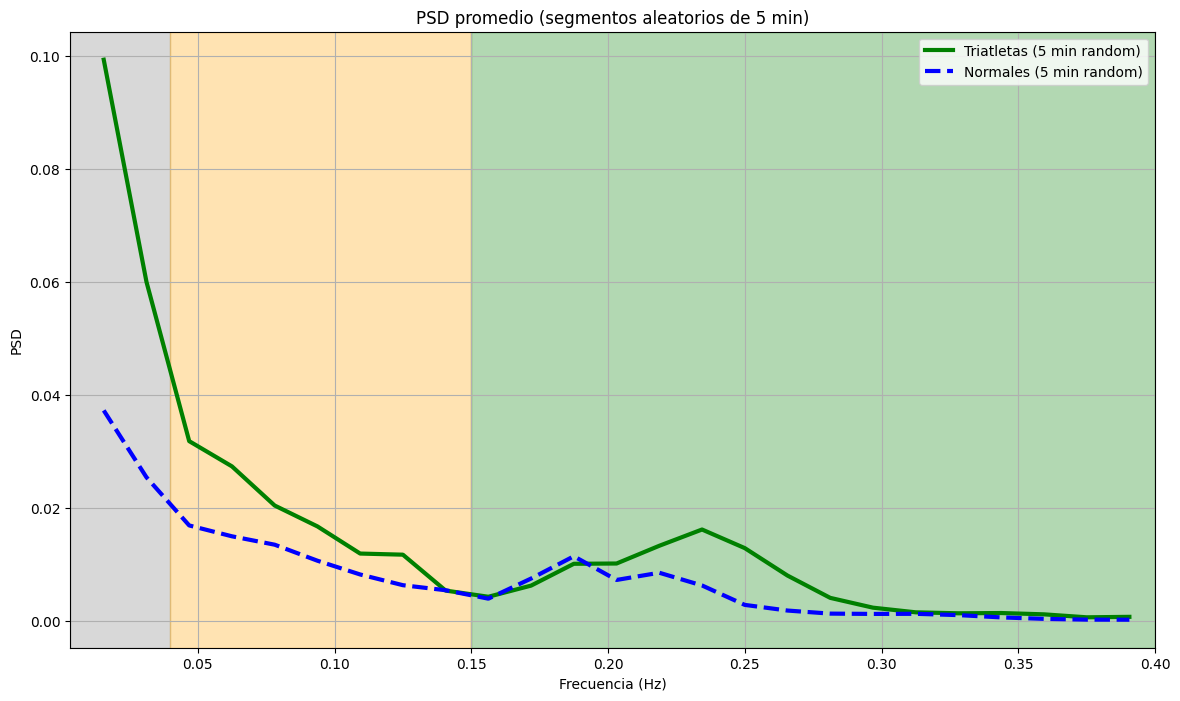

                 VLF        LF        HF
Triatletas  0.001245  0.001673  0.001449
Normales    0.000490  0.001018  0.000853


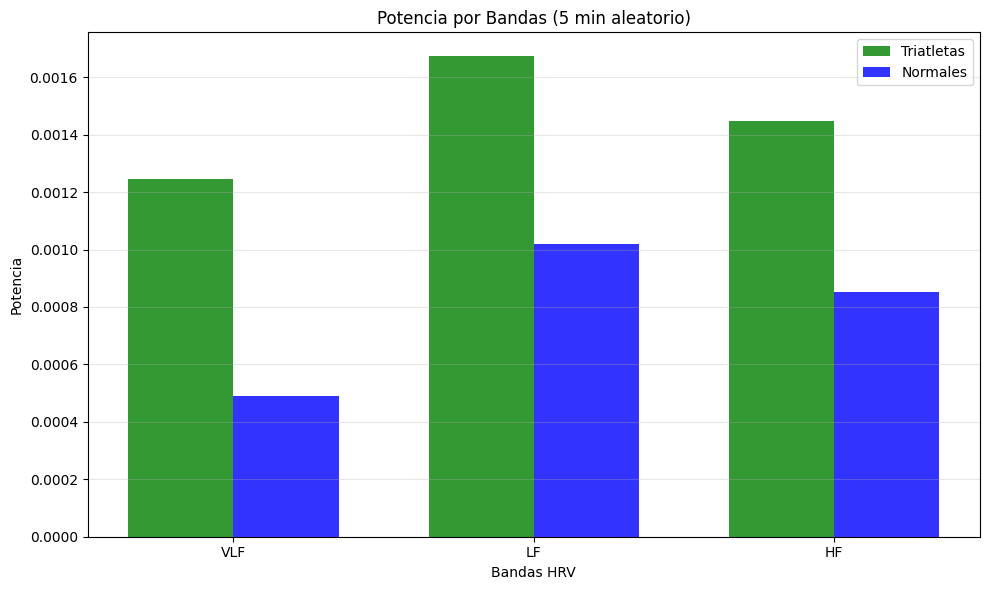

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import pandas as pd

# ============================================
# Montar Drive
# ============================================

from google.colab import drive
drive.mount('/content/drive')

# ============================================
# Paths
# ============================================

triatleta_paths = [
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I9_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I8_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I7_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I6_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I5_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I4_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I3_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I2_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I1_RR.txt"
]

normal_paths = [
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N11_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N10_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N9_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N8_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N7_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N6_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N5_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N4_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N2_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N1_RR.txt"
]

# ============================================
# Bandas HRV
# ============================================

bands = {
    "VLF": (0.0033, 0.04),
    "LF": (0.04, 0.15),
    "HF": (0.15, 0.40)
}

band_colors = {
    "VLF": "gray",
    "LF": "orange",
    "HF": "green"
}

# ============================================
# Funciones
# ============================================

def load_rr(path):
    rr = np.loadtxt(path)
    if np.mean(rr) > 10:
        rr = rr / 1000
    return rr


def get_random_5min_segment(rr, duration=300):
    """
    Extrae un segmento aleatorio de 5 minutos basado en tiempo acumulado
    """
    t = np.cumsum(rr)

    if t[-1] < duration:
        raise ValueError("Registro menor a 5 minutos")

    start_time = np.random.uniform(0, t[-1] - duration)
    end_time = start_time + duration

    mask = (t >= start_time) & (t <= end_time)

    return rr[mask]


def compute_psd(rr):
    fs = 4

    t = np.cumsum(rr)
    t_interp = np.arange(0, t[-1], 1/fs)
    rr_interp = np.interp(t_interp, t, rr)

    f, psd = welch(rr_interp, fs=fs, nperseg=256)

    return f, psd


def band_power(f, psd):
    power = {}
    for band in bands:
        low, high = bands[band]
        mask = (f >= low) & (f <= high)
        power[band] = np.trapezoid(psd[mask], f[mask])
    return power


# ============================================
# TRIATLETAS (ventanas aleatorias)
# ============================================

psd_triatletas = []

for path in triatleta_paths:
    rr = load_rr(path)

    try:
        rr_seg = get_random_5min_segment(rr)
        f_tri, psd_tri = compute_psd(rr_seg)
        psd_triatletas.append(psd_tri)
    except:
        continue  # descarta registros cortos

psd_triatletas = np.array(psd_triatletas)
psd_tri_mean = np.mean(psd_triatletas, axis=0)

f_common = f_tri


# ============================================
# NORMALES (ventanas aleatorias + interpolación)
# ============================================

psd_normales = []

for path in normal_paths:
    rr = load_rr(path)

    try:
        rr_seg = get_random_5min_segment(rr)
        f_norm, psd_norm = compute_psd(rr_seg)

        psd_interp = np.interp(f_common, f_norm, psd_norm)
        psd_normales.append(psd_interp)
    except:
        continue

psd_normales = np.array(psd_normales)
psd_norm_mean = np.mean(psd_normales, axis=0)


# ============================================
# GRAFICA PSD
# ============================================

plt.figure(figsize=(14,8))

f_min, f_max = 0.0033, 0.40
mask = (f_common >= f_min) & (f_common <= f_max)

for band in bands:
    low, high = bands[band]
    plt.axvspan(low, high, color=band_colors[band], alpha=0.3)

# PSD Triatletas (VERDE)
plt.plot(f_common[mask], psd_tri_mean[mask],
         linewidth=3, color='green', label="Triatletas (5 min random)")

# PSD Normales (AZUL)
plt.plot(f_common[mask], psd_norm_mean[mask],
         linewidth=3, linestyle="--", color='blue',
         label="Normales (5 min random)")

plt.xlim(f_min, f_max)

plt.title("PSD promedio (segmentos aleatorios de 5 min)")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD")
plt.legend()
plt.grid()

plt.show()


# ============================================
# POTENCIA POR BANDAS
# ============================================

power_tri = band_power(f_common, psd_tri_mean)
power_norm = band_power(f_common, psd_norm_mean)

df = pd.DataFrame({
    "Triatletas": power_tri,
    "Normales": power_norm
}).T

print(df)


# ============================================
# BARRAS (VERDE Y AZUL)
# ============================================

fig, ax = plt.subplots(figsize=(10,6))

# Crear gráfico de barras con colores personalizados
x = np.arange(len(bands))
width = 0.35

# Barras para triatletas (verde) y normales (azul)
bars_tri = ax.bar(x - width/2, [power_tri[band] for band in bands],
                   width, label='Triatletas', color='green', alpha=0.8)
bars_norm = ax.bar(x + width/2, [power_norm[band] for band in bands],
                    width, label='Normales', color='blue', alpha=0.8)

ax.set_xlabel('Bandas HRV')
ax.set_ylabel('Potencia')
ax.set_title('Potencia por Bandas (5 min aleatorio)')
ax.set_xticks(x)
ax.set_xticklabels(bands.keys())
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# **BOXPLOTS POR BBANDAS CON VALORES ATÍPICOS**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Procesando triatletas...
Procesando normales...

Datos procesados:
        VLF        LF        HF     LF/HF      Subject       Group
0  0.000255  0.000096  0.000072  1.328635  listo_I9_RR  Triatletas
1  0.000204  0.001074  0.005264  0.204059  listo_I8_RR  Triatletas
2  0.001962  0.003281  0.001185  2.769517  listo_I7_RR  Triatletas
3  0.000319  0.000392  0.000487  0.804806  listo_I6_RR  Triatletas
4  0.000350  0.001402  0.000392  3.572632  listo_I5_RR  Triatletas

Total de sujetos: 19
Triatletas: 9
Normales: 10

Generando boxplot para VLF...


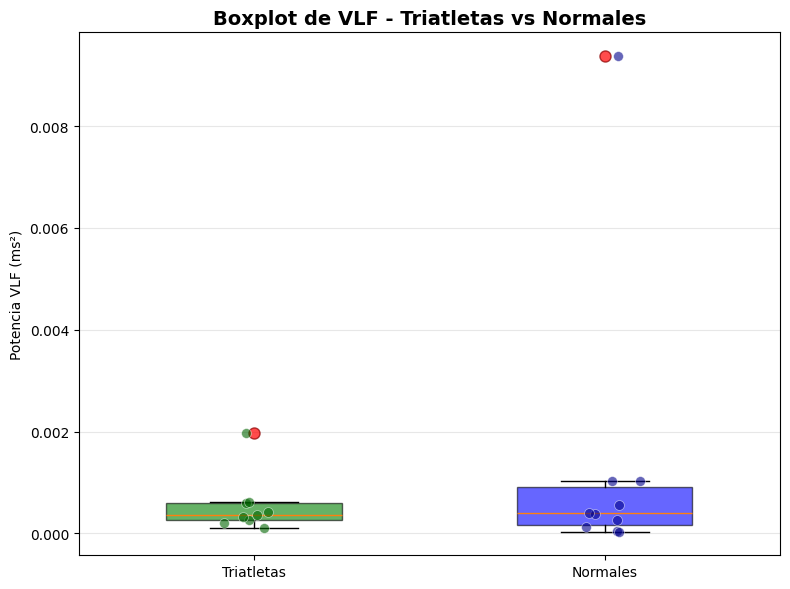


Generando boxplot para LF...


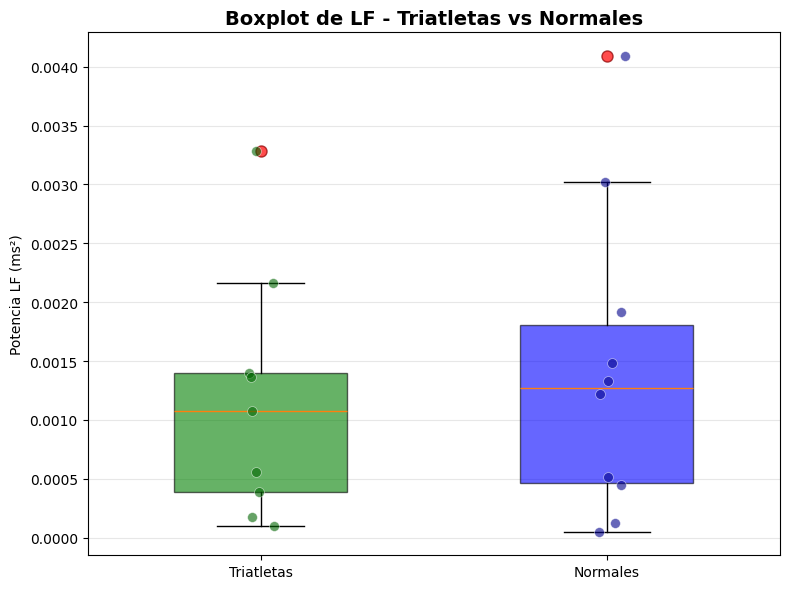


Generando boxplot para HF...


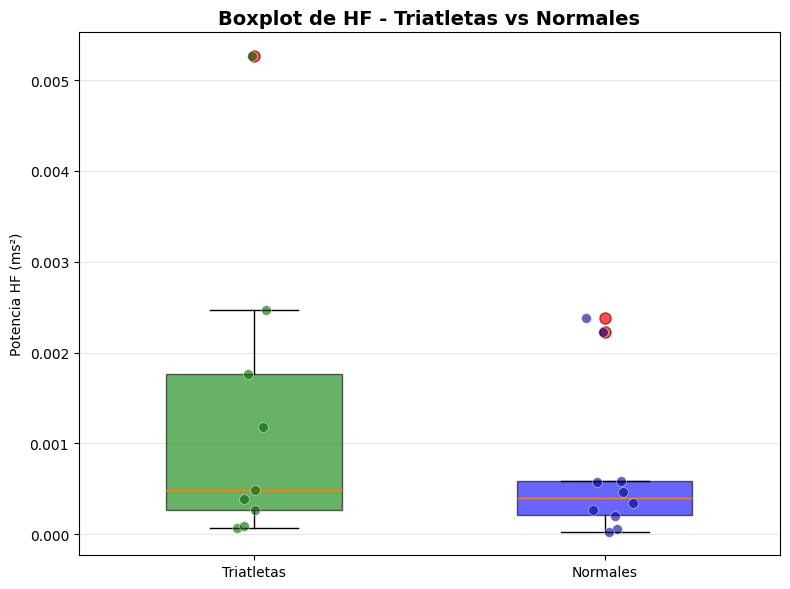


Generando boxplot para LF/HF...


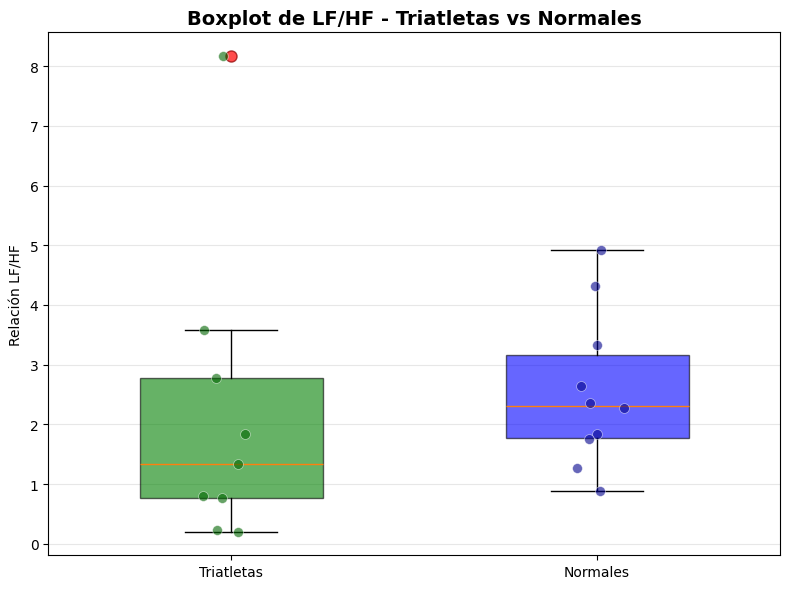


RESUMEN ESTADÍSTICO

--- VLF ---
Triatletas: μ=0.0005, σ=0.0006, min=0.0001, max=0.0020
Normales:   μ=0.0013, σ=0.0029, min=0.0000, max=0.0094

Valores atípicos en Triatletas:
  - listo_I7_RR : 0.0020

Valores atípicos en Normales:
  - listo_N5_RR : 0.0094

--- LF ---
Triatletas: μ=0.0012, σ=0.0010, min=0.0001, max=0.0033
Normales:   μ=0.0014, σ=0.0013, min=0.0001, max=0.0041

Valores atípicos en Triatletas:
  - listo_I7_RR : 0.0033

Valores atípicos en Normales:
  - listo_N5_RR : 0.0041

--- HF ---
Triatletas: μ=0.0013, σ=0.0017, min=0.0001, max=0.0053
Normales:   μ=0.0007, σ=0.0009, min=0.0000, max=0.0024

Valores atípicos en Triatletas:
  - listo_I8_RR : 0.0053

Valores atípicos en Normales:
  - listo_N5_RR : 0.0022
  - listo_N4_RR : 0.0024

--- LF/HF ---
Triatletas: μ=2.1877, σ=2.5146, min=0.2041, max=8.1691
Normales:   μ=2.5584, σ=1.2919, min=0.8838, max=4.9232

Valores atípicos en Triatletas:
  - listo_I4_RR : 8.1691


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import pandas as pd

# ============================================
# Montar Drive
# ============================================

from google.colab import drive
drive.mount('/content/drive')

# ============================================
# Paths
# ============================================

triatleta_paths = [
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I9_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I8_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I7_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I6_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I5_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I4_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I3_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I2_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I1_RR.txt"
]

normal_paths = [
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N11_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N10_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N9_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N8_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N7_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N6_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N5_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N4_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N2_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N1_RR.txt"
]

# ============================================
# Bandas HRV
# ============================================

bands = {
    "VLF": (0.0033, 0.04),
    "LF": (0.04, 0.15),
    "HF": (0.15, 0.40)
}

# ============================================
# Funciones
# ============================================

def load_rr(path):

    rr = np.loadtxt(path)

    # convertir ms -> s
    if np.mean(rr) > 10:
        rr = rr / 1000

    return rr


def get_random_5min_segment(rr, duration=300):

    t = np.cumsum(rr)

    if t[-1] < duration:
        raise ValueError("Registro menor a 5 minutos")

    start_time = np.random.uniform(0, t[-1] - duration)

    end_time = start_time + duration

    mask = (t >= start_time) & (t <= end_time)

    rr_segment = rr[mask]

    if len(rr_segment) < 10:
        raise ValueError("Segmento demasiado pequeño")

    return rr_segment


def compute_psd(rr):

    fs = 4

    t = np.cumsum(rr)

    t_interp = np.arange(0, t[-1], 1/fs)

    rr_interp = np.interp(t_interp, t, rr)

    f, psd = welch(rr_interp, fs=fs, nperseg=256)

    return f, psd


def band_power(f, psd):

    power = {}

    for band in bands:

        low, high = bands[band]

        mask = (f >= low) & (f <= high)

        power[band] = np.trapezoid(psd[mask], f[mask])

    return power


def compute_all_metrics(paths_list, group_name):

    all_metrics = []

    for path in paths_list:

        try:

            rr = load_rr(path)

            rr_seg = get_random_5min_segment(rr)

            f, psd = compute_psd(rr_seg)

            power = band_power(f, psd)

            # Evitar división entre cero
            if power["HF"] > 0:
                power["LF/HF"] = power["LF"] / power["HF"]
            else:
                power["LF/HF"] = np.nan

            power["Subject"] = path.split("/")[-1].replace(".txt", "")

            power["Group"] = group_name

            all_metrics.append(power)

        except Exception as e:

            print(f"Error procesando {path}: {e}")

            continue

    return pd.DataFrame(all_metrics)


# ============================================
# CALCULAR MÉTRICAS
# ============================================

print("Procesando triatletas...")
df_tri = compute_all_metrics(triatleta_paths, "Triatletas")

print("Procesando normales...")
df_norm = compute_all_metrics(normal_paths, "Normales")

# combinar
df_all = pd.concat([df_tri, df_norm], ignore_index=True)

print("\nDatos procesados:")
print(df_all.head())

print(f"\nTotal de sujetos: {len(df_all)}")
print(f"Triatletas: {len(df_tri)}")
print(f"Normales: {len(df_norm)}")


# ============================================
# FUNCIÓN PARA BOXPLOTS
# ============================================

def plot_boxplot_with_points(metric_name, ylabel, title=None):

    if title is None:
        title = metric_name

    fig, ax = plt.subplots(figsize=(8,6))

    data_tri = df_tri[metric_name].dropna()

    data_norm = df_norm[metric_name].dropna()

    data = [data_tri, data_norm]

    box = ax.boxplot(
        data,
        patch_artist=True,
        widths=0.5,
        showfliers=True,
        flierprops=dict(
            marker='o',
            markerfacecolor='red',
            markersize=8,
            markeredgecolor='darkred',
            alpha=0.7
        )
    )

    # colores
    box['boxes'][0].set(facecolor='green', alpha=0.6)

    box['boxes'][1].set(facecolor='blue', alpha=0.6)

    # puntos individuales
    for i, d in enumerate(data):

        x = np.random.normal(i + 1, 0.04, size=len(d))

        color = 'darkgreen' if i == 0 else 'darkblue'

        ax.scatter(
            x,
            d,
            alpha=0.6,
            color=color,
            s=50,
            edgecolors='white',
            linewidth=0.5,
            zorder=3
        )

    ax.set_xticks([1,2])

    ax.set_xticklabels(['Triatletas', 'Normales'])

    ax.set_ylabel(ylabel)

    ax.set_title(title, fontsize=14, fontweight='bold')

    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()

    plt.show()


# ============================================
# GENERAR BOXPLOTS
# ============================================

metrics_config = {
    "VLF": "Potencia VLF (ms²)",
    "LF": "Potencia LF (ms²)",
    "HF": "Potencia HF (ms²)",
    "LF/HF": "Relación LF/HF"
}

for metric, ylabel in metrics_config.items():

    print(f"\nGenerando boxplot para {metric}...")

    plot_boxplot_with_points(
        metric,
        ylabel,
        f"Boxplot de {metric} - Triatletas vs Normales"
    )


# ============================================
# RESUMEN ESTADÍSTICO
# ============================================

print("\n" + "="*60)
print("RESUMEN ESTADÍSTICO")
print("="*60)

for metric in ["VLF", "LF", "HF", "LF/HF"]:

    print(f"\n--- {metric} ---")

    tri_stats = df_tri[metric].describe()

    norm_stats = df_norm[metric].describe()

    print(
        f"Triatletas: μ={tri_stats['mean']:.4f}, "
        f"σ={tri_stats['std']:.4f}, "
        f"min={tri_stats['min']:.4f}, "
        f"max={tri_stats['max']:.4f}"
    )

    print(
        f"Normales:   μ={norm_stats['mean']:.4f}, "
        f"σ={norm_stats['std']:.4f}, "
        f"min={norm_stats['min']:.4f}, "
        f"max={norm_stats['max']:.4f}"
    )

    # detectar outliers
    for df_group, name in [(df_tri, 'Triatletas'),
                           (df_norm, 'Normales')]:

        Q1 = df_group[metric].quantile(0.25)

        Q3 = df_group[metric].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR

        upper_bound = Q3 + 1.5 * IQR

        outliers = df_group[
            (df_group[metric] < lower_bound) |
            (df_group[metric] > upper_bound)
        ]

        if len(outliers) > 0:

            print(f"\nValores atípicos en {name}:")

            for _, row in outliers.iterrows():

                print(
                    f"  - {row['Subject']} : "
                    f"{row[metric]:.4f}"
                )

## **BOXPLOTS POR BANDAS SIN VALORES ATÍPICOS**


Generando boxplot SIN valores atípicos para VLF...


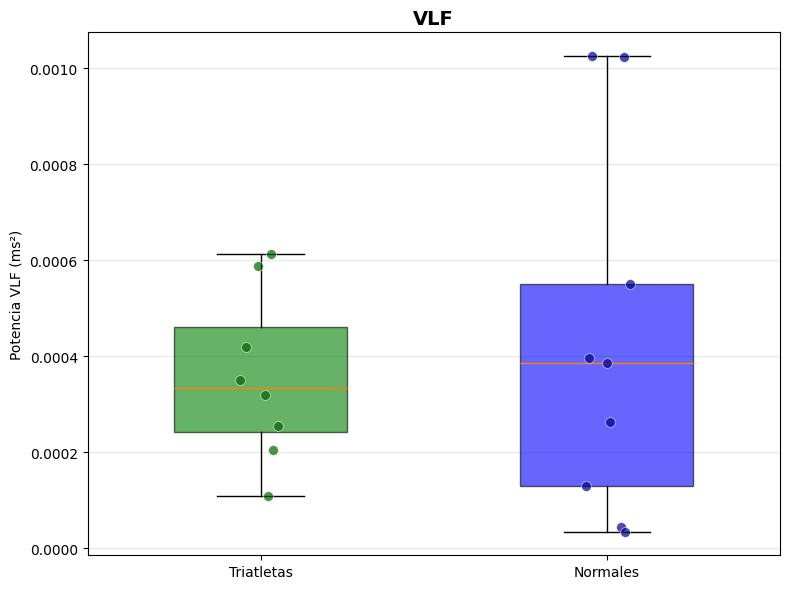


Generando boxplot SIN valores atípicos para LF...


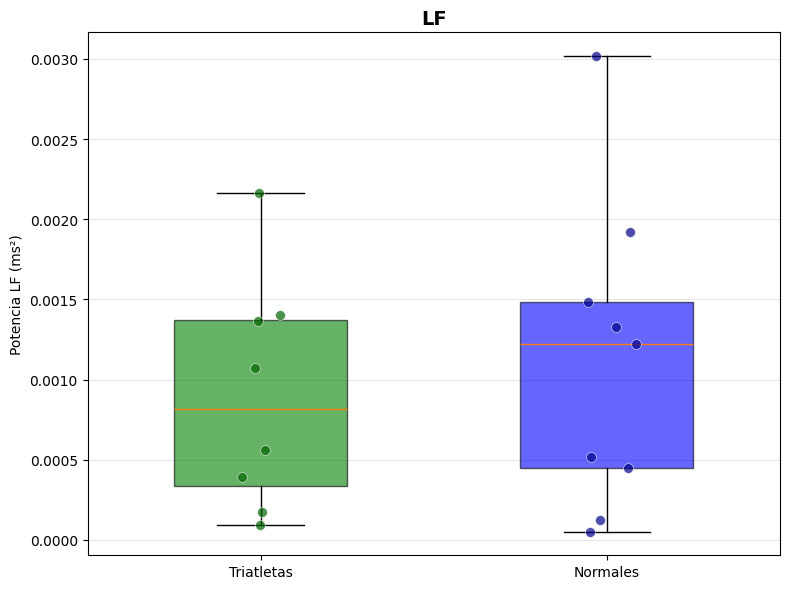


Generando boxplot SIN valores atípicos para HF...


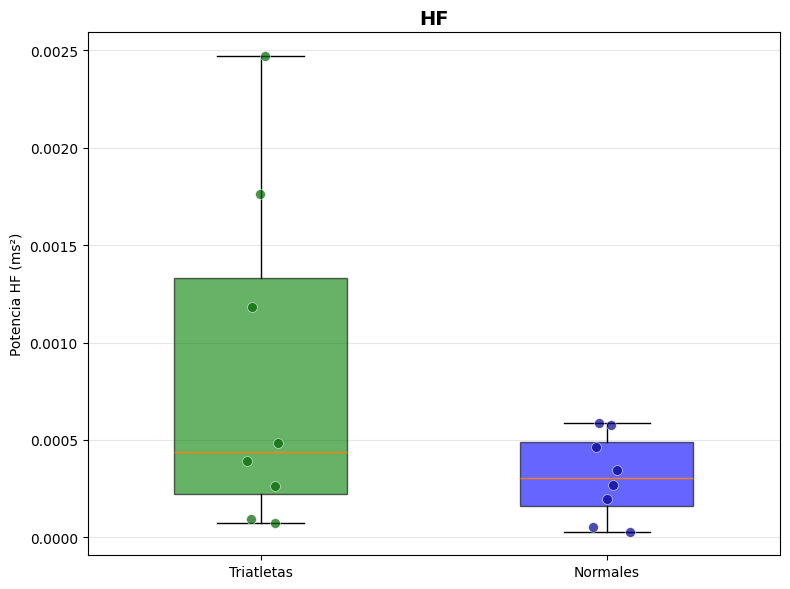


Generando boxplot SIN valores atípicos para LF/HF...


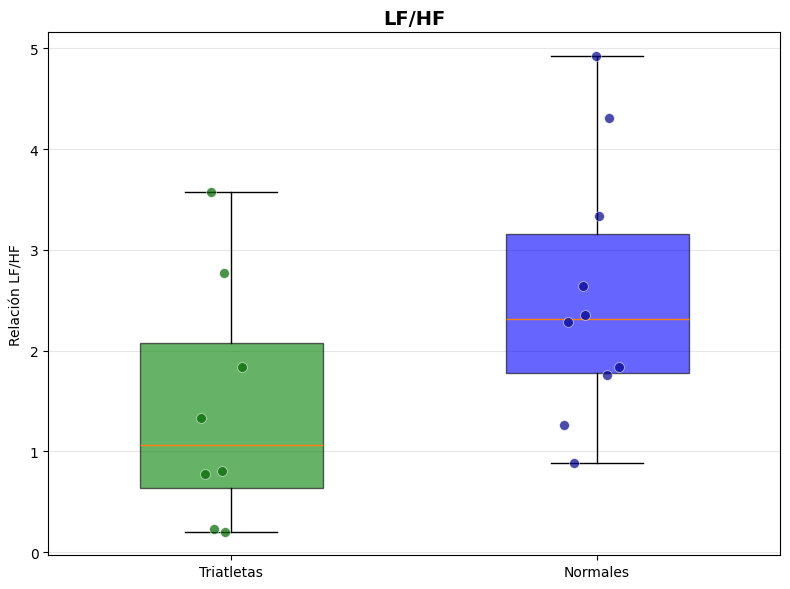


RESUMEN ESTADÍSTICO SIN VALORES ATÍPICOS

--- VLF ---
Triatletas: μ=0.0004, σ=0.0002, n=8
Normales:   μ=0.0004, σ=0.0004, n=9

--- LF ---
Triatletas: μ=0.0009, σ=0.0007, n=8
Normales:   μ=0.0011, σ=0.0010, n=9

--- HF ---
Triatletas: μ=0.0008, σ=0.0009, n=8
Normales:   μ=0.0003, σ=0.0002, n=8

--- LF/HF ---
Triatletas: μ=1.4400, σ=1.2151, n=8
Normales:   μ=2.5584, σ=1.2919, n=10


In [ ]:
# ============================================
# FUNCIÓN PARA ELIMINAR VALORES ATÍPICOS (IQR)
# ============================================

def remove_outliers_iqr(df, metric):

    Q1 = df[metric].quantile(0.25)

    Q3 = df[metric].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR

    upper_bound = Q3 + 1.5 * IQR

    filtered_df = df[
        (df[metric] >= lower_bound) &
        (df[metric] <= upper_bound)
    ]

    return filtered_df


# ============================================
# ELIMINAR OUTLIERS PARA CADA MÉTRICA
# ============================================

filtered_data = {}

for metric in ["VLF", "LF", "HF", "LF/HF"]:

    df_tri_filtered = remove_outliers_iqr(df_tri, metric)

    df_norm_filtered = remove_outliers_iqr(df_norm, metric)

    filtered_data[metric] = {
        "tri": df_tri_filtered,
        "norm": df_norm_filtered
    }


# ============================================
# FUNCIÓN DE BOXPLOT SIN OUTLIERS
# ============================================

def plot_boxplot_without_outliers(metric_name, ylabel, title=None):

    if title is None:
        title = metric_name

    fig, ax = plt.subplots(figsize=(8,6))

    # datos filtrados
    data_tri = filtered_data[metric_name]["tri"][metric_name].dropna()

    data_norm = filtered_data[metric_name]["norm"][metric_name].dropna()

    data = [data_tri, data_norm]

    # boxplot
    box = ax.boxplot(
        data,
        patch_artist=True,
        widths=0.5,
        showfliers=False
    )

    # colores
    box['boxes'][0].set(facecolor='green', alpha=0.6)

    box['boxes'][1].set(facecolor='blue', alpha=0.6)

    # puntos individuales
    for i, d in enumerate(data):

        x = np.random.normal(i + 1, 0.04, size=len(d))

        color = 'darkgreen' if i == 0 else 'darkblue'

        ax.scatter(
            x,
            d,
            alpha=0.7,
            color=color,
            s=50,
            edgecolors='white',
            linewidth=0.5,
            zorder=3
        )

    ax.set_xticks([1,2])

    ax.set_xticklabels(['Triatletas', 'Normales'])

    ax.set_ylabel(ylabel)

    ax.set_title(title, fontsize=14, fontweight='bold')

    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()

    plt.show()


# ============================================
# GENERAR BOXPLOTS SIN OUTLIERS
# ============================================

metrics_config = {
    "VLF": "Potencia VLF (ms²)",
    "LF": "Potencia LF (ms²)",
    "HF": "Potencia HF (ms²)",
    "LF/HF": "Relación LF/HF"
}

for metric, ylabel in metrics_config.items():

    print(f"\nGenerando boxplot SIN valores atípicos para {metric}...")

    plot_boxplot_without_outliers(
        metric,
        ylabel,
        f"{metric}"
    )


# ============================================
# NUEVO RESUMEN ESTADÍSTICO SIN OUTLIERS
# ============================================

print("\n" + "="*60)
print("RESUMEN ESTADÍSTICO SIN VALORES ATÍPICOS")
print("="*60)

for metric in ["VLF", "LF", "HF", "LF/HF"]:

    print(f"\n--- {metric} ---")

    tri_data = filtered_data[metric]["tri"][metric]

    norm_data = filtered_data[metric]["norm"][metric]

    print(
        f"Triatletas: μ={tri_data.mean():.4f}, "
        f"σ={tri_data.std():.4f}, "
        f"n={len(tri_data)}"
    )

    print(
        f"Normales:   μ={norm_data.mean():.4f}, "
        f"σ={norm_data.std():.4f}, "
        f"n={len(norm_data)}"
    )

## **RR MEAN, SDNN, RMSSD, PNN50 & HR**

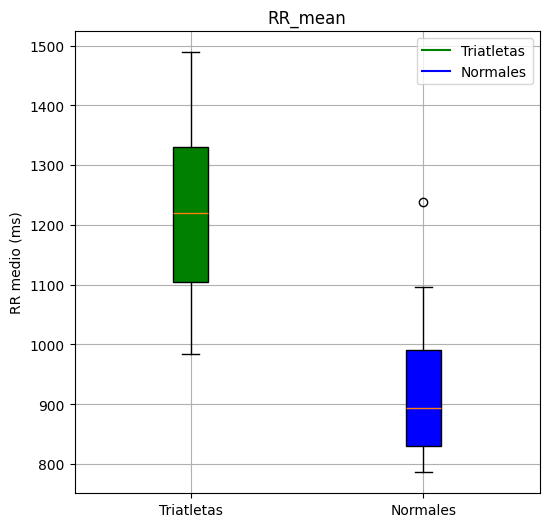

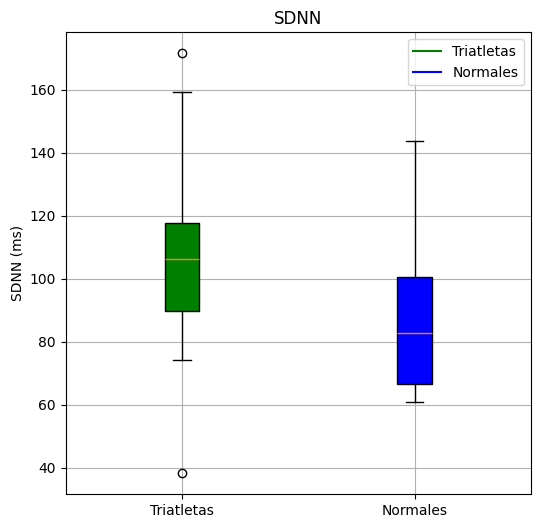

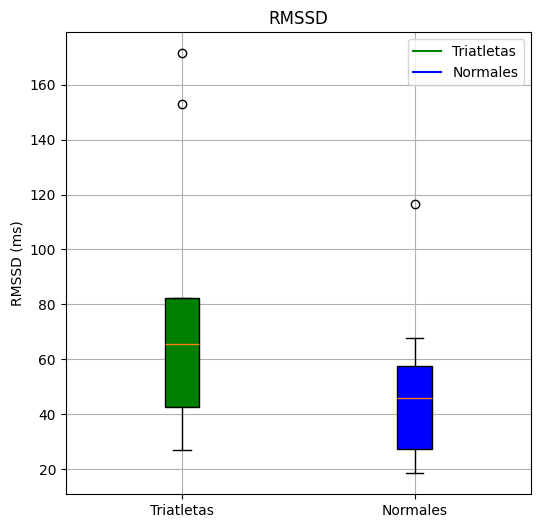

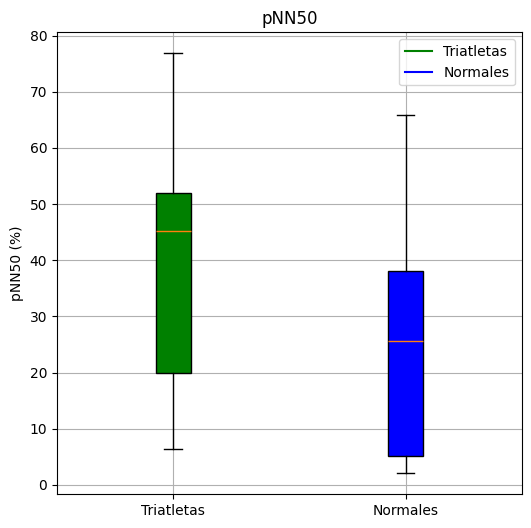

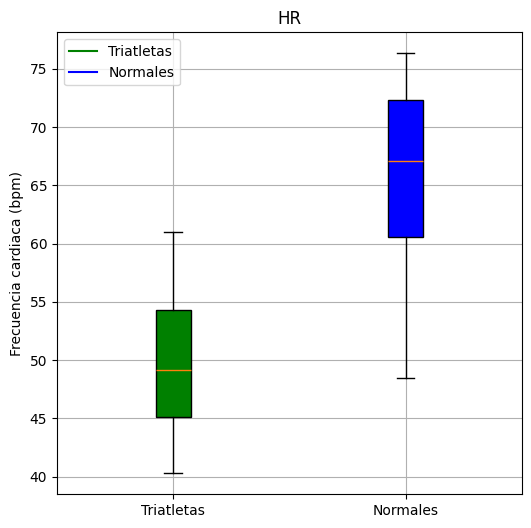

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ============================================
# FUNCIONES HRV (DOMINIO DEL TIEMPO)
# ============================================

def compute_time_domain_metrics(rr):

    # Asegurar segundos
    if np.mean(rr) > 10:
        rr = rr / 1000

    rr_ms = rr * 1000  # convertir a ms

    # RR medio
    mean_rr = np.mean(rr_ms)

    # SDNN
    sdnn = np.std(rr_ms, ddof=1)

    # RMSSD
    diff_rr = np.diff(rr_ms)
    rmssd = np.sqrt(np.mean(diff_rr**2))

    # pNN50
    nn50 = np.sum(np.abs(diff_rr) > 50)
    pnn50 = (nn50 / len(diff_rr)) * 100

    # Frecuencia cardiaca media (HR)
    hr = 60 / np.mean(rr)  # bpm

    return {
        "RR_mean": mean_rr,
        "SDNN": sdnn,
        "RMSSD": rmssd,
        "pNN50": pnn50,
        "HR": hr
    }

# ============================================
# CALCULO POR GRUPO
# ============================================

def compute_group_time_metrics(paths):
    metrics = []

    for p in paths:
        rr = np.loadtxt(p)
        m = compute_time_domain_metrics(rr)
        metrics.append(m)

    return pd.DataFrame(metrics)

df_tri_time = compute_group_time_metrics(triatleta_paths)
df_norm_time = compute_group_time_metrics(normal_paths)

# ============================================
# FUNCION BOXPLOT
# ============================================

def plot_box(metric_name, ylabel):

    plt.figure(figsize=(6,6))

    data = [df_tri_time[metric_name], df_norm_time[metric_name]]

    box = plt.boxplot(data, patch_artist=True)

    # Triatletas en verde, Normales en azul
    box['boxes'][0].set(facecolor='green')
    box['boxes'][1].set(facecolor='blue')

    plt.xticks([1,2], ["Triatletas", "Normales"])
    plt.title(metric_name)
    plt.ylabel(ylabel)

    # Leyenda
    plt.plot([], [], color='green', label='Triatletas')
    plt.plot([], [], color='blue', label='Normales')
    plt.legend()

    plt.grid()
    plt.show()

# ============================================
# GRAFICAS INDIVIDUALES
# ============================================

plot_box("RR_mean", "RR medio (ms)")
plot_box("SDNN", "SDNN (ms)")
plot_box("RMSSD", "RMSSD (ms)")
plot_box("pNN50", "pNN50 (%)")
plot_box("HR", "Frecuencia cardiaca (bpm)")

## **PSD ESCALA SEMILOGARÍTMICA**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


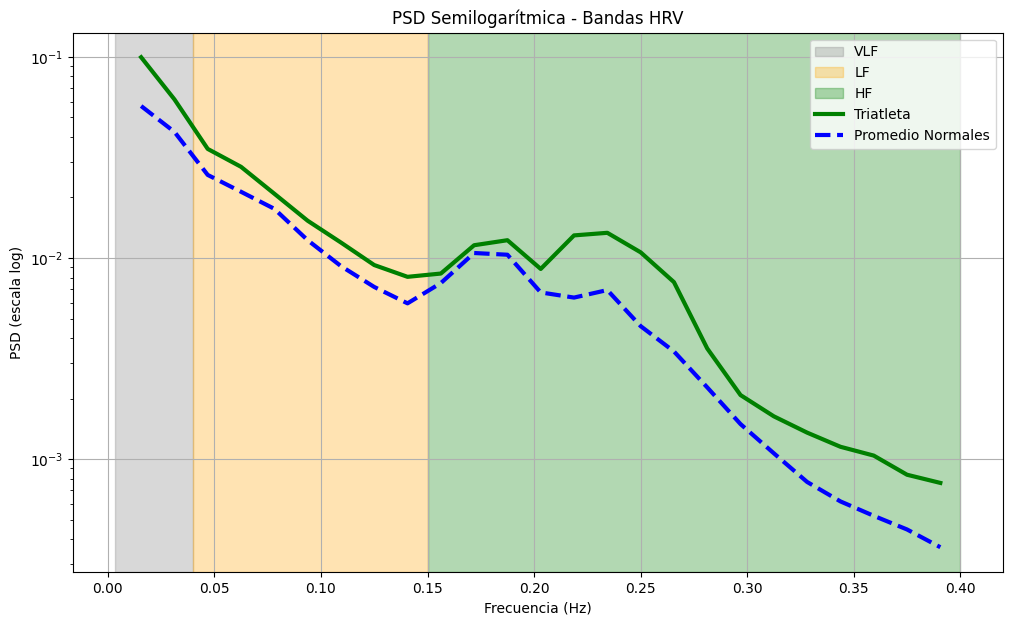

In [ ]:
# ============================================
# PSD SEMILOG - TRIATLETA VS PROMEDIO NORMALES
# SOLO BANDAS VLF, LF, HF
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ============================================
# Montar Drive
# ============================================

from google.colab import drive
drive.mount('/content/drive')

# ============================================
# Paths
# ============================================

triatleta_paths = [

"/content/drive/MyDrive/Triatleta/Triatleta/listo_I9_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I8_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I7_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I6_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I5_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I4_RR.txt",
 "/content/drive/MyDrive/Triatleta/Triatleta/listo_I3_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I2_RR.txt",
"/content/drive/MyDrive/Triatleta/Triatleta/listo_I1_RR.txt"

]

normal_paths = [

"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N11_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N10_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N9_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N8_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N7_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N6_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N5_RR.txt",
"/content/drive/MyDrive/Triatleta/Gente Normal/listo_N4_RR.txt"

]

# ============================================
# Bandas HRV
# ============================================

bands = {

"VLF": (0.0033, 0.04),

"LF": (0.04, 0.15),

"HF": (0.15, 0.40)

}

# ============================================
# FUNCIONES
# ============================================

def load_rr(path):

    rr = np.loadtxt(path)

    if np.mean(rr) > 10:

        rr = rr / 1000

    return rr


def compute_psd(rr):

    fs = 4

    t = np.cumsum(rr)

    t_interp = np.arange(0, t[-1], 1/fs)

    rr_interp = np.interp(t_interp, t, rr)

    f, psd = welch(rr_interp, fs=fs, nperseg=256)

    return f, psd


# ============================================
# PSD TRIATLETA
# ============================================

psd_triatletas_list = []
# We assume the frequency array 'f' will be consistent across all files for the same fs and nperseg.
# We'll store the 'f' from the last processed triathlete file to use for plotting.
representative_f = None
for path in triatleta_paths:
    rr = load_rr(path)
    current_f, current_psd = compute_psd(rr)
    psd_triatletas_list.append(current_psd)
    if representative_f is None:
        representative_f = current_f

f = representative_f
psd_tri_mean = np.mean(psd_triatletas_list, axis=0)


# ============================================
# PSD NORMALES
# ============================================

psd_normales = []

for path in normal_paths:

    rr = load_rr(path)

    f_norm, psd_norm = compute_psd(rr)

    psd_normales.append(psd_norm)


psd_norm_mean = np.mean(psd_normales, axis=0)


# ============================================
# FILTRAR SOLO HASTA HF
# ============================================

mask = (f >= 0.0033) & (f <= 0.40)

f_plot = f[mask]

psd_tri_plot = psd_tri_mean[mask] # Changed to use psd_tri_mean

psd_norm_plot = psd_norm_mean[mask]


# ============================================
# GRAFICA SEMILOG
# ============================================

plt.figure(figsize=(12,7))


# sombrear bandas

colors = {

"VLF":"gray",

"LF":"orange",

"HF":"green"

}

for band in bands:

    low, high = bands[band]

    plt.axvspan(low, high,

                color=colors[band],

                alpha=0.3,

                label=band)


# curvas

plt.semilogy(

f_plot,

psd_tri_plot,

linewidth=3,

color='green',

label="Triatleta"

)


plt.semilogy(

f_plot,

psd_norm_plot,

linewidth=3,

linestyle="--",

color='blue',

label="Promedio Normales"

)


# etiquetas

plt.title("PSD Semilogarítmica - Bandas HRV")

plt.xlabel("Frecuencia (Hz)")

plt.ylabel("PSD (escala log)")

plt.legend()

plt.grid(True)

plt.show()
